In [ ]:
#folder_path = "/content/drive/MyDrive/nouvelair_df"

#dfs = []

#for file in os.listdir(folder_path):
    #if file.endswith(".xlsx") or file.endswith(".xls"):
        #file_path = os.path.join(folder_path, file)
        #df = pd.read_excel(file_path)
        #dfs.append(df)

#df = pd.concat(dfs, ignore_index=True)
#Convert DataFrame to CSV format
#df.to_csv("output.csv", index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/output.csv')
df = df.drop(columns=['COMPARE PRICE',"DIFF PRICE ",'COMPARE DISPO'])
df.dtypes

JOUR                object
MOIS                 int64
DATE DEPART         object
N° VOL              object
VILLE DE DEPART     object
VILLE D'ARRIVEE     object
TIME DEPART         object
TIME ARRIVEE        object
CLASS               object
CODE                object
PRIX TTC           float64
DISPONIBILITE        int64
dtype: object

In [ ]:
df.head()

,JOUR,MOIS,DATE DEPART,N° VOL,VILLE DE DEPART,VILLE D'ARRIVEE,TIME DEPART,TIME ARRIVEE,CLASS,CODE,PRIX TTC,DISPONIBILITE
0,Jeudi,2,29/02/2024,BJ-520,Tunis,Paris - Charles de Gaulle,16:00,18:35,1,1OWC1OFR,193.0,3
1,Jeudi,2,29/02/2024,BJ-521,Paris - Charles de Gaulle,Tunis,19:35,22:05,T,TOWC1IFR,177.0,9
2,Jeudi,2,29/02/2024,BJ-508,Djerba,Paris - Charles de Gaulle,15:00,18:05,2,2OWC1OFR,237.0,1
3,Jeudi,2,29/02/2024,BJ-598,Tunis,Lyon,16:30,18:25,Y,YOWC1OFR,737.0,0
4,Jeudi,2,29/02/2024,BJ-509,Paris - Charles de Gaulle,Djerba,19:05,21:55,Y,YOWC1IFR,770.0,0


In [ ]:
# Removing useless columns
df = df.drop(columns=['N° VOL','CODE'])

# Deleting rows with DISPONIBILITE = 0 or 1
df = df[(df['DISPONIBILITE'] != 0) & (df['DISPONIBILITE'] != 1)]

In [ ]:
df = df[(df['VILLE DE DEPART'] != "Strasbourg-Entzheim") & (df["VILLE D'ARRIVEE"] != "Strasbourg-Entzheim")]

In [ ]:
# Dropping duplicates and keeping the last occurrence
df = df.drop_duplicates(keep='last')
df.shape

(58317, 10)

In [ ]:
# Removing Outliers in PRIX TTC column
df = df[(df['PRIX TTC'] != 1.0) & (df['PRIX TTC'] != 2.0)]
df.shape

(55617, 10)

In [ ]:
df.head()

,JOUR,MOIS,DATE DEPART,VILLE DE DEPART,VILLE D'ARRIVEE,TIME DEPART,TIME ARRIVEE,CLASS,PRIX TTC,DISPONIBILITE
0,Jeudi,2,29/02/2024,Tunis,Paris - Charles de Gaulle,16:00,18:35,1,193.0,3
6,Vendredi,3,01/03/2024,Tunis,Paris - Charles de Gaulle,16:00,18:35,1,193.0,8
7,Vendredi,3,01/03/2024,Tunis,Toulouse,13:00,15:00,Q,171.0,7
11,Vendredi,3,01/03/2024,Paris - Charles de Gaulle,Monastir,18:45,21:20,R,191.0,9
12,Vendredi,3,01/03/2024,Paris - Charles de Gaulle,Tunis,19:35,22:05,R,191.0,9


In [ ]:
# Define a function to convert a column to datetime format
def change_into_datetime(col):
    df[col] = pd.to_datetime(df[col], format='%d/%m/%Y')

# Apply the datetime conversion on 'DATE DEPART'
for i in ['DATE DEPART']:
    change_into_datetime(i)

# Converting to datetime without specifying a date format
def change_into_datetime_time(col):
    df[col] = pd.to_datetime(df[col])

# Apply the datetime conversion on 'TIME DEPART'&'TIME ARRIVEE'
for i in ['TIME DEPART','TIME ARRIVEE']:
    change_into_datetime_time(i)

# Change the data type of the 'CLASS' column to string
df['CLASS'] = df['CLASS'].astype("string")

<ipython-input-11-caaea520df65>:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])
<ipython-input-11-caaea520df65>:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])


In [ ]:
# Creating a 'Day' column from the 'DATE DEPART' column
df['DAY']=df['DATE DEPART'].dt.day

# Extracting the hour & minutes of departure and arrival
df['depart_hour'] = df['TIME DEPART'].dt.hour
df['depart_minute'] = df['TIME DEPART'].dt.minute
df['arrival_hour'] = df['TIME ARRIVEE'].dt.hour
df['arrival_minute'] = df['TIME ARRIVEE'].dt.minute

# Calculate flight duration
df['flight duration'] = df['TIME ARRIVEE'] - df['TIME DEPART']

# Extract hours and minutes from flight duration
df['dur_hour'] = df['flight duration'].apply(lambda x: pd.Timedelta(x).components.hours)
df['dur_min'] = df['flight duration'].apply(lambda x: pd.Timedelta(x).components.minutes)

# Keeping the flight duration in minutes
df['dur_min'] += df['dur_hour'] * 60
df = df.drop(columns=['dur_hour','flight duration'])

In [ ]:
df.head()

,JOUR,MOIS,DATE DEPART,VILLE DE DEPART,VILLE D'ARRIVEE,TIME DEPART,TIME ARRIVEE,CLASS,PRIX TTC,DISPONIBILITE,DAY,depart_hour,depart_minute,arrival_hour,arrival_minute,dur_min
0,Jeudi,2,2024-02-29,Tunis,Paris - Charles de Gaulle,2024-05-28 16:00:00,2024-05-28 18:35:00,1,193.0,3,29,16,0,18,35,155
6,Vendredi,3,2024-03-01,Tunis,Paris - Charles de Gaulle,2024-05-28 16:00:00,2024-05-28 18:35:00,1,193.0,8,1,16,0,18,35,155
7,Vendredi,3,2024-03-01,Tunis,Toulouse,2024-05-28 13:00:00,2024-05-28 15:00:00,Q,171.0,7,1,13,0,15,0,120
11,Vendredi,3,2024-03-01,Paris - Charles de Gaulle,Monastir,2024-05-28 18:45:00,2024-05-28 21:20:00,R,191.0,9,1,18,45,21,20,155
12,Vendredi,3,2024-03-01,Paris - Charles de Gaulle,Tunis,2024-05-28 19:35:00,2024-05-28 22:05:00,R,191.0,9,1,19,35,22,5,150


In [ ]:
df['PRIX TTC'].describe()

count    55617.000000
mean       212.666906
std        134.314079
min         36.600000
25%        121.000000
50%        172.220000
75%        257.000000
max        770.000000
Name: PRIX TTC, dtype: float64

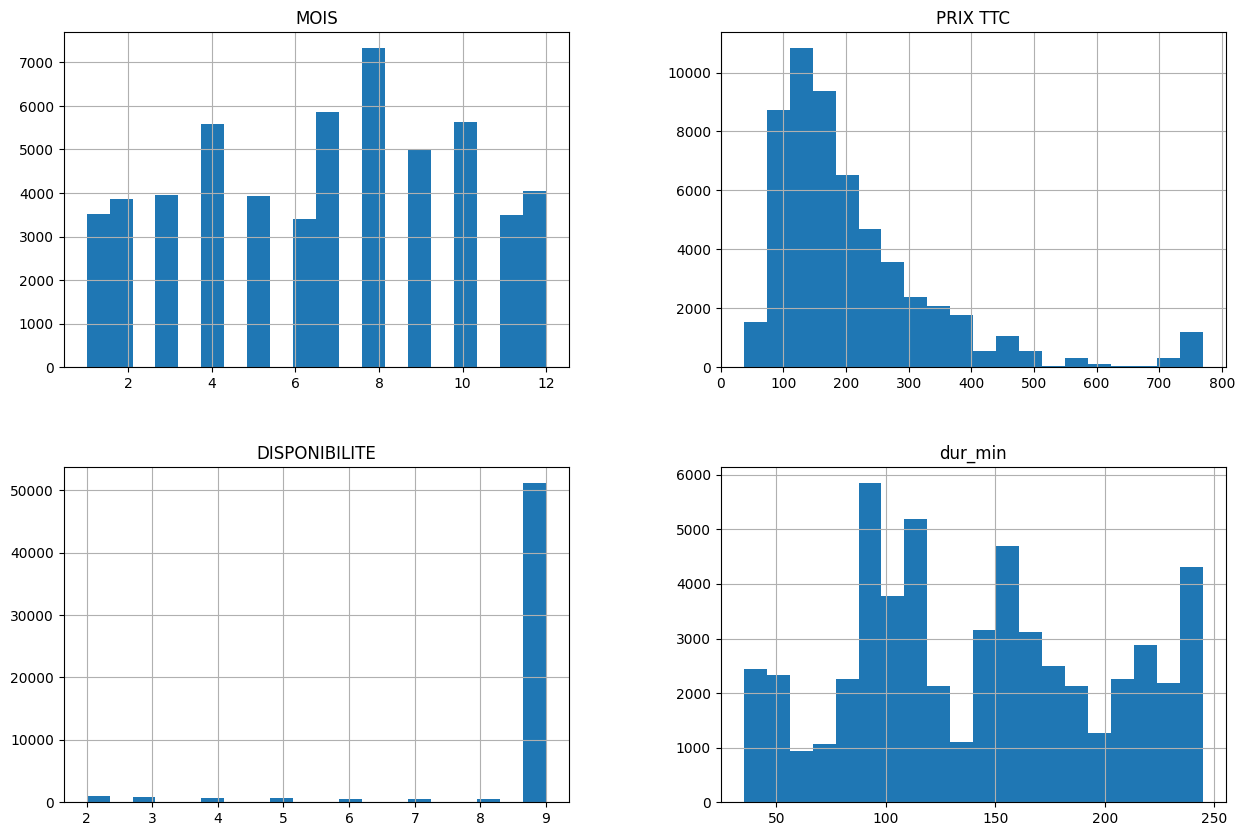

In [ ]:
# Plot histograms for numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_features].hist(bins=20, figsize=(15, 10))
plt.show()

In [ ]:
#OneHotEncoding of VILLE DE DEPART & VILLE D'ARRIVEE columns
Departure = pd.get_dummies(df['VILLE DE DEPART']).add_suffix('_Departure')
Arrival = pd.get_dummies(df["VILLE D'ARRIVEE"]).add_suffix('_Arrival')

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Encoding the 'JOUR' column and storing the result in a new column 'WeekDay'
df['WeekDay'] = label_encoder.fit_transform(df['JOUR'])
# Encoding the 'CLASS' column and replacing original values with encoded ones
df['CLASS'] = label_encoder.fit_transform(df['CLASS'])
df['WeekDay'].unique()

array([1, 6, 5, 0, 2, 4, 3])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Define the features to be scaled
features_to_scale = ['dur_min', 'depart_hour', 'depart_minute', 'arrival_hour', 'arrival_minute']

# Apply Min-Max Scaling
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

df.head()

,JOUR,MOIS,DATE DEPART,VILLE DE DEPART,VILLE D'ARRIVEE,TIME DEPART,TIME ARRIVEE,CLASS,PRIX TTC,DISPONIBILITE,DAY,depart_hour,depart_minute,arrival_hour,arrival_minute,dur_min,WeekDay
0,Jeudi,2,2024-02-29,Tunis,Paris - Charles de Gaulle,2024-05-28 16:00:00,2024-05-28 18:35:00,0,193.0,3,29,0.695652,0.000000,0.782609,0.636364,0.571429,1
6,Vendredi,3,2024-03-01,Tunis,Paris - Charles de Gaulle,2024-05-28 16:00:00,2024-05-28 18:35:00,0,193.0,8,1,0.695652,0.000000,0.782609,0.636364,0.571429,6
7,Vendredi,3,2024-03-01,Tunis,Toulouse,2024-05-28 13:00:00,2024-05-28 15:00:00,15,171.0,7,1,0.565217,0.000000,0.652174,0.000000,0.404762,6
11,Vendredi,3,2024-03-01,Paris - Charles de Gaulle,Monastir,2024-05-28 18:45:00,2024-05-28 21:20:00,16,191.0,9,1,0.782609,0.818182,0.913043,0.363636,0.571429,6
12,Vendredi,3,2024-03-01,Paris - Charles de Gaulle,Tunis,2024-05-28 19:35:00,2024-05-28 22:05:00,16,191.0,9,1,0.826087,0.636364,0.956522,0.090909,0.547619,6


In [ ]:
df = df.drop(columns=['JOUR','DATE DEPART','VILLE DE DEPART',"VILLE D'ARRIVEE",'TIME DEPART','TIME ARRIVEE'])
df.head()

,MOIS,CLASS,PRIX TTC,DISPONIBILITE,DAY,depart_hour,depart_minute,arrival_hour,arrival_minute,dur_min,WeekDay
0,2,0,193.0,3,29,0.695652,0.000000,0.782609,0.636364,0.571429,1
6,3,0,193.0,8,1,0.695652,0.000000,0.782609,0.636364,0.571429,6
7,3,15,171.0,7,1,0.565217,0.000000,0.652174,0.000000,0.404762,6
11,3,16,191.0,9,1,0.782609,0.818182,0.913043,0.363636,0.571429,6
12,3,16,191.0,9,1,0.826087,0.636364,0.956522,0.090909,0.547619,6


In [ ]:
df['PRIX TTC'].describe()

count    55617.000000
mean       212.666906
std        134.314079
min         36.600000
25%        121.000000
50%        172.220000
75%        257.000000
max        770.000000
Name: PRIX TTC, dtype: float64

In [ ]:
final_df=pd.concat([df,Departure,Arrival],axis=1)

In [ ]:
final_df.columns

Index(['MOIS', 'CLASS', 'PRIX TTC', 'DISPONIBILITE', 'DAY', 'depart_hour',
       'depart_minute', 'arrival_hour', 'arrival_minute', 'dur_min', 'WeekDay',
       'Bordeaux_Departure', 'Djerba_Departure', 'Lille_Departure',
       'Lyon_Departure', 'Marseille_Departure', 'Monastir_Departure',
       'Nantes_Departure', 'Nice_Departure',
       'Paris - Charles de Gaulle_Departure', 'Strasbourg_Departure',
       'Toulouse_Departure', 'Tunis_Departure', 'Bordeaux_Arrival',
       'Djerba_Arrival', 'Lille_Arrival', 'Lyon_Arrival', 'Marseille_Arrival',
       'Monastir_Arrival', 'Nantes_Arrival', 'Nice_Arrival',
       'Paris - Charles de Gaulle_Arrival', 'Strasbourg_Arrival',
       'Toulouse_Arrival', 'Tunis_Arrival'],
      dtype='object')

Model: XGBRegressor
R2 score: 0.9969
MAE: 4.1901
RMSE: 7.4992


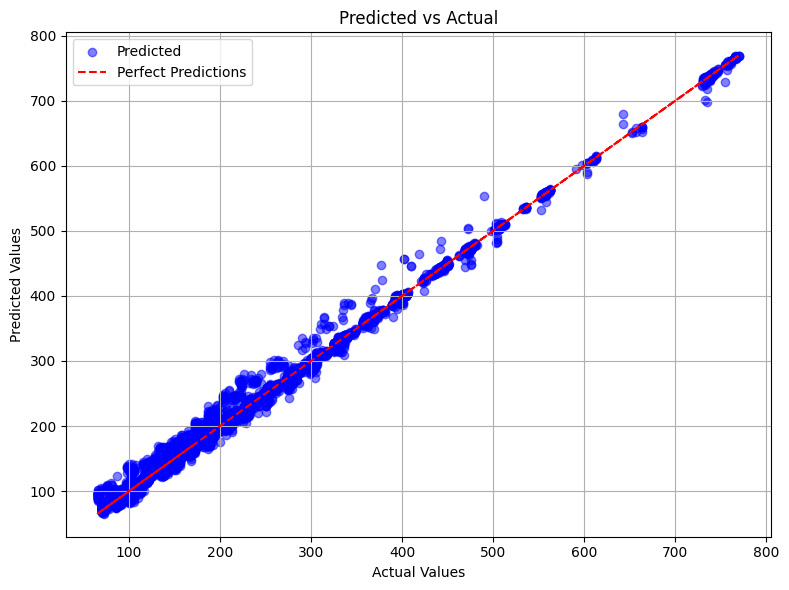

In [ ]:
# Import necessary libraries
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt  # Import matplotlib

def plot_predicted_vs_actual(actual, predicted):
    plt.figure(figsize=(8, 6))
    plt.scatter(actual, predicted, color='blue', alpha=0.5, label='Predicted')
    plt.plot(actual, actual, color='red', linestyle='--', label='Perfect Predictions')  # Diagonal line representing perfect predictions
    plt.title('Predicted vs Actual')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()  # Adjust layout to prevent clipping of labels
    plt.show()

# Splitting the dataset into features (X) and target variable (y)
X = final_df.drop('PRIX TTC', axis=1)  # Features
y = final_df['PRIX TTC']  # Target variable

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Creating an XGBRegressor model
model = XGBRegressor()

# Training the model on the training data
model.fit(X_train, y_train)

# Making predictions on the test set
predictions = model.predict(X_test)

print("Model: XGBRegressor")

# Calculating and printing the R-squared score
r2score = r2_score(y_test, predictions)
print("R2 score: {:.4f}".format(r2score))

# Calculating and printing the Mean Absolute Error (MAE)
print('MAE: {:.4f}'.format(mean_absolute_error(y_test, predictions)))

# Calculating and printing the Root Mean Squared Error (RMSE)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print('RMSE: {:.4f}'.format(rmse))

# Plotting predicted vs actual values
plot_predicted_vs_actual(y_test, predictions)

In [ ]:
# Import necessary libraries
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Splitting the dataset into features (X) and target variable (y)
X=final_df.drop('PRIX TTC',axis=1) # Features
y=final_df['PRIX TTC'] # Target variable

# Splitting the dataset into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

# Creating a RandomForestRegressor model
model = RandomForestRegressor()

# Training the model on the training data
model.fit(X_train, y_train)

# Making predictions on the test set
predictions = model.predict(X_test)

print("Model: RandomForestRegressor")

# Calculating and printing the R-squared score
r2score=r2_score(y_test,predictions)
print("R2 score: {:.4f}".format(r2score))

# Calculating and printing the Mean Absolute Error (MAE)
print('MAE: {:.4f}'.format(mean_absolute_error(y_test,predictions)))

# Calculating and printing the Root Mean Squared Error (RMSE)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print('RMSE: {:.4f}'.format(rmse))

Model: RandomForestRegressor
R2 score: 0.9955
MAE: 4.6492
RMSE: 9.0125


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor

# Splitting the dataset into features (X) and target variable (y)
X=final_df.drop('PRIX TTC',axis=1) # Features
y=final_df['PRIX TTC'] # Target variable

# Splitting the dataset into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

# Creating an ExtraTreesRegressor model
model2 = ExtraTreesRegressor()

# Training the model on the training data
model2.fit(X_train, y_train)

# Making predictions on the test set
predictions = model2.predict(X_test)

print("Model: ExtraTreesRegressor")

# Calculating and printing the R-squared score
r2score=r2_score(y_test,predictions)
print("R2 score: {:.4f}".format(r2score))

# Calculating and printing the Mean Absolute Error (MAE)
print('MAE: {:.4f}'.format(mean_absolute_error(y_test,predictions)))

# Calculating and printing the Root Mean Squared Error (RMSE)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print('RMSE: {:.4f}'.format(rmse))

Model: ExtraTreesRegressor
R2 score: 0.9943
MAE: 4.8841
RMSE: 10.1039


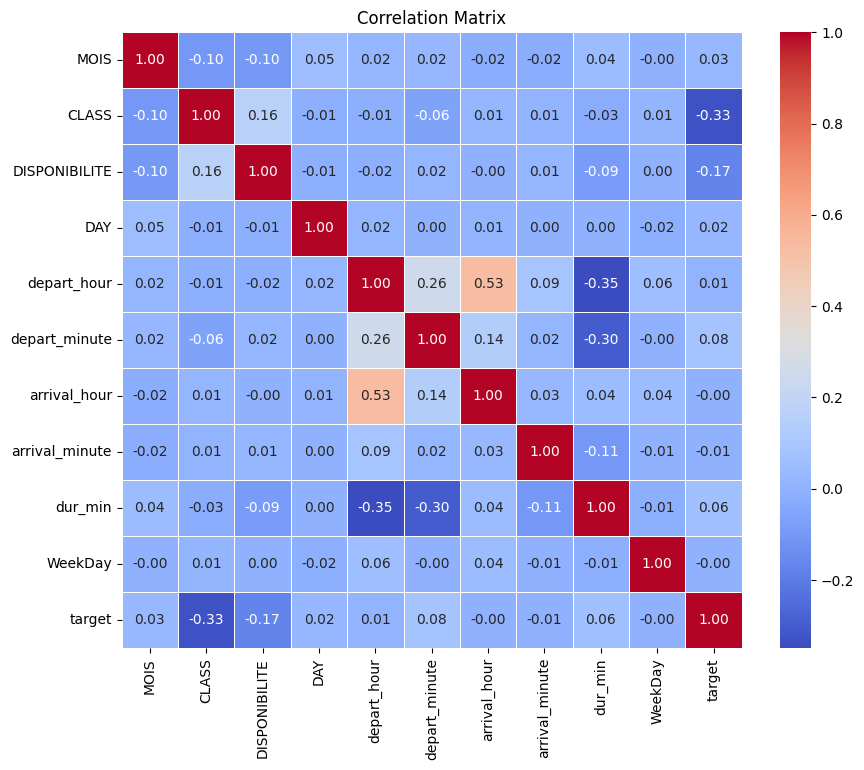

In [ ]:
X=df.drop('PRIX TTC',axis=1)
y=df['PRIX TTC']

# Combine features and target variable into a single DataFrame
data = pd.concat([X, pd.Series(y, name='target')], axis=1)

# Compute correlation matrix
correlation_matrix = data.corr()

# Plot heatmap of correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
#import joblib

# Save the trained model to a file
#joblib.dump(model2, 'model.pkl')